
=== Gráfica de las dos series ===


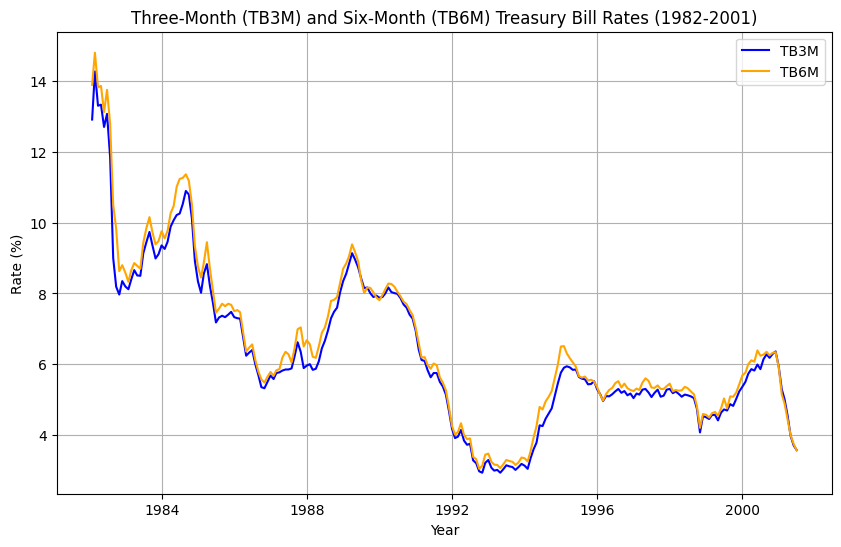


Observaciones:
- Las series TB3M y TB6M se mueven juntas, con TB6M generalmente por encima de TB3M.
- Ambas tasas alcanzan un máximo en los 1980s (~14-15%) y disminuyen gradualmente hasta niveles de 3-6% en los 2000s.
- Esto refleja una prima por plazo, ya que las tasas a 6 meses son más altas debido al mayor riesgo.

=== ADF en niveles (TB3M y TB6M) ===

Unit Root Test for TB3M:
ADF Statistic: -1.5391858164849086
p-value: 0.514045363282407
Critical Values: {'1%': np.float64(-3.460018927623594), '5%': np.float64(-2.8745897386146817), '10%': np.float64(-2.57372514086348)}
TB3M is not stationary (fail to reject null hypothesis).

Unit Root Test for TB6M:
ADF Statistic: -3.7738194363438047
p-value: 0.003186826077188909
Critical Values: {'1%': np.float64(-3.458854867412691), '5%': np.float64(-2.8740800599399323), '10%': np.float64(-2.573453223097503)}
TB6M is stationary (reject null hypothesis).

=== ADF en primeras diferencias (TB3M y TB6M) ===

Unit Root Test for TB3M (first difference)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
import statsmodels.api as sm

# Cargar los datos
tb3m = [12.92000, 14.28000, 13.31000, 13.34000, 12.71000, 13.08000, 11.86000, 9.000000, 8.190000, 7.970000, 8.350000, 8.200000, 8.120000, 8.390000, 8.660000, 8.510000, 8.500000, 9.140000, 9.450000, 9.740000, 9.360000, 8.990000, 9.110000, 9.360000, 9.260000, 9.460000, 9.890000, 10.07000, 10.22000, 10.26000, 10.53000, 10.90000, 10.80000, 10.12000, 8.920000, 8.340000, 8.020000, 8.560000, 8.830000, 8.220000, 7.730000, 7.180000, 7.320000, 7.370000, 7.330000, 7.400000, 7.480000, 7.330000, 7.300000, 7.290000, 6.760000, 6.240000, 6.330000, 6.400000, 6.000000, 5.690000, 5.350000, 5.320000, 5.500000, 5.680000, 5.580000, 5.750000, 5.770000, 5.820000, 5.850000, 5.850000, 5.880000, 6.230000, 6.620000, 6.350000, 5.890000, 5.960000, 6.000000, 5.840000, 5.870000, 6.080000, 6.450000, 6.660000, 6.950000, 7.300000, 7.480000, 7.600000, 8.030000, 8.350000, 8.560000, 8.840000, 9.140000, 8.960000, 8.740000, 8.430000, 8.150000, 8.170000, 8.010000, 7.900000, 7.940000, 7.880000, 7.900000, 8.000000, 8.170000, 8.040000, 8.010000, 7.990000, 7.870000, 7.690000, 7.600000, 7.400000, 7.290000, 6.950000, 6.410000, 6.120000, 6.090000, 5.830000, 5.630000, 5.750000, 5.750000, 5.500000, 5.370000, 5.140000, 4.690000, 4.180000, 3.910000, 3.950000, 4.140000, 3.840000, 3.720000, 3.750000, 3.280000, 3.200000, 2.970000, 2.930000, 3.210000, 3.290000, 3.070000, 2.990000, 3.010000, 2.930000, 3.030000, 3.140000, 3.110000, 3.090000, 3.010000, 3.090000, 3.180000, 3.130000, 3.040000, 3.330000, 3.590000, 3.780000, 4.270000, 4.250000, 4.460000, 4.610000, 4.750000, 5.100000, 5.450000, 5.760000, 5.900000, 5.940000, 5.910000, 5.840000, 5.850000, 5.640000, 5.590000, 5.570000, 5.430000, 5.440000, 5.520000, 5.290000, 5.150000, 4.960000, 5.100000, 5.090000, 5.150000, 5.230000, 5.300000, 5.190000, 5.240000, 5.120000, 5.170000, 5.040000, 5.170000, 5.140000, 5.280000, 5.300000, 5.200000, 5.070000, 5.190000, 5.280000, 5.080000, 5.110000, 5.280000, 5.300000, 5.180000, 5.230000, 5.160000, 5.080000, 5.140000, 5.120000, 5.090000, 5.040000, 4.740000, 4.070000, 4.530000, 4.500000, 4.450000, 4.560000, 4.570000, 4.410000, 4.630000, 4.720000, 4.690000, 4.870000, 4.820000, 5.020000, 5.230000, 5.360000, 5.500000, 5.730000, 5.860000, 5.820000, 5.990000, 5.860000, 6.14000, 6.28000, 6.18000, 6.29000, 6.36000, 5.94000, 5.29000, 5.01000, 4.54000, 3.97000, 3.70000, 3.57000]
tb6m = [13.90000, 14.81000, 13.83000, 13.87000, 13.13000, 13.76000, 12.80000, 10.51000, 9.830000, 8.630000, 8.800000, 8.590000, 8.330000, 8.650000, 8.860000, 8.780000, 8.700000, 9.440000, 9.850000, 10.16000, 9.730000, 9.390000, 9.480000, 9.760000, 9.560000, 9.770000, 10.27000, 10.47000, 11.02000, 11.24000, 11.27000, 11.37000, 11.19000, 10.52000, 9.340000, 8.760000, 8.450000, 8.870000, 9.450000, 8.710000, 8.070000, 7.460000, 7.570000, 7.710000, 7.640000, 7.710000, 7.680000, 7.500000, 7.530000, 7.470000, 6.890000, 6.360000, 6.470000, 6.560000, 6.120000, 5.790000, 5.570000, 5.480000, 5.640000, 5.780000, 5.670000, 5.830000, 5.860000, 6.190000, 6.350000, 6.280000, 6.050000, 6.460000, 6.990000, 7.040000, 6.500000, 6.680000, 6.560000, 6.210000, 6.180000, 6.500000, 6.890000, 7.040000, 7.350000, 7.790000, 7.820000, 7.900000, 8.300000, 8.700000, 8.850000, 9.050000, 9.390000, 9.170000, 8.910000, 8.380000, 8.010000, 8.170000, 8.160000, 8.030000, 7.890000, 7.810000, 7.960000, 8.120000, 8.280000, 8.270000, 8.190000, 8.050000, 7.920000, 7.770000, 7.700000, 7.530000, 7.390000, 7.030000, 6.580000, 6.190000, 6.200000, 5.980000, 5.870000, 6.020000, 5.970000, 5.630000, 5.480000, 5.260000, 4.800000, 4.260000, 4.010000, 4.080000, 4.330000, 4.000000, 3.880000, 3.900000, 3.380000, 3.310000, 3.040000, 3.130000, 3.440000, 3.470000, 3.240000, 3.160000, 3.150000, 3.060000, 3.170000, 3.290000, 3.260000, 3.240000, 3.150000, 3.220000, 3.360000, 3.340000, 3.250000, 3.530000, 3.920000, 4.250000, 4.790000, 4.720000, 4.950000, 5.080000, 5.240000, 5.620000, 5.980000, 6.500000, 6.510000, 6.310000, 6.170000, 6.050000, 5.930000, 5.660000, 5.620000, 5.650000, 5.540000, 5.560000, 5.510000, 5.350000, 5.130000, 4.970000, 5.160000, 5.270000, 5.330000, 5.460000, 5.520000, 5.340000, 5.450000, 5.320000, 5.270000, 5.240000, 5.310000, 5.270000, 5.480000, 5.600000, 5.530000, 5.340000, 5.330000, 5.400000, 5.300000, 5.300000, 5.380000, 5.450000, 5.230000, 5.270000, 5.250000, 5.260000, 5.360000, 5.320000, 5.230000, 5.150000, 4.810000, 4.200000, 4.590000, 4.570000, 4.490000, 4.610000, 4.650000, 4.540000, 4.750000, 5.030000, 4.750000, 5.090000, 5.080000, 5.200000, 5.430000, 5.680000, 5.760000, 6.000000, 6.110000, 6.070000, 6.390000, 6.240000, 6.270000, 6.350000, 6.250000, 6.320000, 6.340000, 5.920000, 5.150000, 4.890000, 4.440000, 3.990000, 3.740000, 3.560000]

# Generar fechas
dates = pd.date_range(start='1982-01-01', end='2001-06-30', freq='ME')

# Crear DataFrame
df = pd.DataFrame({'TB3M': tb3m, 'TB6M': tb6m}, index=dates)

# Función para el test ADF
def test_stationarity(timeseries, name):
    result = adfuller(timeseries)
    print(f'\nUnit Root Test for {name}:')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:', result[4])
    if result[1] <= 0.05:
        print(f"{name} is stationary (reject null hypothesis).")
    else:
        print(f"{name} is not stationary (fail to reject null hypothesis).")

# a. Graficar las dos series
print("\n=== Gráfica de las dos series ===")
plt.figure(figsize=(10, 6))
plt.plot(df['TB3M'], label='TB3M', color='blue')
plt.plot(df['TB6M'], label='TB6M', color='orange')
plt.title('Three-Month (TB3M) and Six-Month (TB6M) Treasury Bill Rates (1982-2001)')
plt.xlabel('Year')
plt.ylabel('Rate (%)')
plt.legend()
plt.grid()
plt.show()

print("\nObservaciones:")
print("- Las series TB3M y TB6M se mueven juntas, con TB6M generalmente por encima de TB3M.")
print("- Ambas tasas alcanzan un máximo en los 1980s (~14-15%) y disminuyen gradualmente hasta niveles de 3-6% en los 2000s.")
print("- Esto refleja una prima por plazo, ya que las tasas a 6 meses son más altas debido al mayor riesgo.")

# b. ADF en niveles
print("\n=== ADF en niveles (TB3M y TB6M) ===")
test_stationarity(df['TB3M'], 'TB3M')
test_stationarity(df['TB6M'], 'TB6M')

# ADF en primeras diferencias
print("\n=== ADF en primeras diferencias (TB3M y TB6M) ===")
tb3m_diff = df['TB3M'].diff().dropna()
tb6m_diff = df['TB6M'].diff().dropna()
test_stationarity(tb3m_diff, 'TB3M (first difference)')
test_stationarity(tb6m_diff, 'TB6M (first difference)')

# c. Test de cointegración (usando coint)
print("\n=== Test de cointegración (usando coint) ===")
result = coint(df['TB3M'], df['TB6M'])
print('Test Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[2])
if result[1] <= 0.05:
    print("TB3M y TB6M están cointegradas (rechazamos la hipótesis nula).")
else:
    print("TB3M y TB6M no están cointegradas (no rechazamos la hipótesis nula).")

# Regresión de cointegración (TB6M ~ TB3M) y ADF sobre los residuos
print("\n=== Regresión de cointegración (TB6M ~ TB3M) ===")
X = sm.add_constant(df['TB3M'])
model = sm.OLS(df['TB6M'], X).fit()
print(model.summary())

print("\n=== ADF sobre los residuos ===")
residuals = model.resid
test_stationarity(residuals, 'Residuals')

# d. Significado económico de la cointegración
print("\n=== Significado económico de la cointegración ===")
print("La cointegración implica que las tasas TB3M y TB6M tienen una relación estable de largo plazo, consistente con la teoría de la estructura de plazos.")
print("Esto sugiere que las tasas de interés a 3 y 6 meses están vinculadas a través de las expectativas del mercado y la prima por plazo.")
print("Cualquier desviación temporal entre las tasas se corrige con el tiempo.")

print("\nSi no estuvieran cointegradas:")
print("- Podría indicar mercados segmentados, con tasas a 3 y 6 meses operando de manera independiente.")
print("- También podría reflejar expectativas divergentes o incertidumbre económica.")
print("- Sería más difícil usar estas tasas para predecir movimientos futuros o modelar relaciones de largo plazo.")

# e. Uso de un VAR
print("\n=== Uso de un VAR con 4 rezagos ===")
print("Dado que las series están cointegradas, es válido estimar un VAR en niveles.")
print("La cointegración asegura que existe una relación de largo plazo que el VAR puede capturar, evitando problemas de regresión espuria.")
print("No es necesario usar primeras diferencias, ya que la cointegración permite modelar en niveles.")